# K04_03 California Housing Lineare Regression

Letzter Update am 27. Mai 2026

**Dozentenversion**

Diese Fassung enthält kurze Musterlösungen und didaktische Hinweise für den Einsatz in der Vorlesung.

# Variante A: Lineares Regressionsmodell mit einem Merkmal (nur MedInc=Median Income)

## A.1. Bibliotheken importieren

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## A.2. Die California Housing-Daten laden

| Kürzel          | Englische Bezeichnung | Deutsche Übersetzung                 | Bedeutung                                                 |
| --------------- | --------------------- | ------------------------------------ | --------------------------------------------------------- |
| **MedInc**      | Median Income         | Median-Einkommen                     | Medianes Haushaltseinkommen im Block (in Zehntausend USD) |
| **HouseAge**    | House Age             | Durchschnittliches Gebäudealter      | Durchschnittliches Alter der Wohngebäude                  |
| **AveRooms**    | Average Rooms         | Durchschnittliche Zimmeranzahl       | Ø Anzahl Zimmer pro Haushalt                              |
| **AveBedrms**   | Average Bedrooms      | Durchschnittliche Schlafzimmeranzahl | Ø Anzahl Schlafzimmer pro Haushalt                        |
| **Population**  | Population            | Bevölkerungszahl                     | Anzahl der Einwohner im Block                             |
| **AveOccup**    | Average Occupancy     | Durchschnittliche Belegung           | Ø Anzahl Personen pro Haushalt                            |
| **Latitude**    | Latitude              | Breitengrad                          | Geografische Breite (Nord-Süd-Lage)                       |
| **Longitude**   | Longitude             | Längengrad                           | Geografische Länge (Ost-West-Lage)                        |
| **MedHouseVal** | Median House Value    | Medianer Hauspreis                   | Zielvariable: Hauspreis (in 100.000 USD)                  |

Achtung: Alle Häuser die in Wirklichkeit mehr als 500.000 USD wert waren,
wurden trotzdem mit dem Wert 5.0 eingetragen.


In [2]:
# Lineare Regression mit dem California Housing Dataset

california = fetch_california_housing(as_frame=True)

X = california.data[["MedInc"]]   # Nur Median Income
y = california.target             # Median House Value
X.shape

(20640, 1)

## A.3. Train/Test-Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    # stratify nicht verfügbar bei Regression (y ist kontinuierlich, keine Klassen)
)

print(f"Trainingsdaten: {len(X_train):>6} Samples")
print(f"Testdaten:      {len(X_test):>6} Samples")

Trainingsdaten:  16512 Samples
Testdaten:        4128 Samples


## A.4. Lineares Regressionsmodell trainieren

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

# --------------------------------------------------
# Modellparameter ausgeben
# --------------------------------------------------
print("Lineares Regressionsmodell (nur MedInc)")
print("---------------------------------------")
print(f"Achsenabschnitt (β₀): {model.intercept_:.3f}")
print(f"Koeffizient (β₁):     {model.coef_[0]:.3f}")
print()

Lineares Regressionsmodell (nur MedInc)
---------------------------------------
Achsenabschnitt (β₀): 0.445
Koeffizient (β₁):     0.419



### Interpretation der Modellparameter

Das Modell hat die Form: **y = β1 · MedInc + β0**

- **β0 (Achsenabschnitt):** Vorhergesagter Hauspreis bei einem Einkommen von 0
  (theoretischer Basiswert, in 100.000 USD)
- **β1 (Koeffizient für MedInc):** Pro zusätzliche Einheit Median-Einkommen
  (= 10.000 USD Haushaltseinkommen) steigt der vorhergesagte Hauspreis um
  diesen Betrag (in 100.000 USD)

> **Beispiel:** Koeffizient = 0.42 bedeutet: Ein Block mit 10.000 USD höherem
> Medianeinkommen hat im Modell einen um ~42.000 USD höheren Hauspreis.


## A.4. Vorhersage und Modellgüte


In [5]:
y_pred_a = model.predict(X_test)

rmse_a = np.sqrt(mean_squared_error(y_test, y_pred_a))
r2_a   = r2_score(y_test, y_pred_a)

print("Modellgüte (Variante A – nur MedInc)")
print("--------------------------------------")
print(f"RMSE: {rmse_a:.3f}  (mittlerer Fehler in 100.000 USD)")
print(f"R²:   {r2_a:.3f}  (Anteil erklärter Varianz)")


Modellgüte (Variante A – nur MedInc)
--------------------------------------
RMSE: 0.842  (mittlerer Fehler in 100.000 USD)
R²:   0.459  (Anteil erklärter Varianz)


## A.5. Visualisierung

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


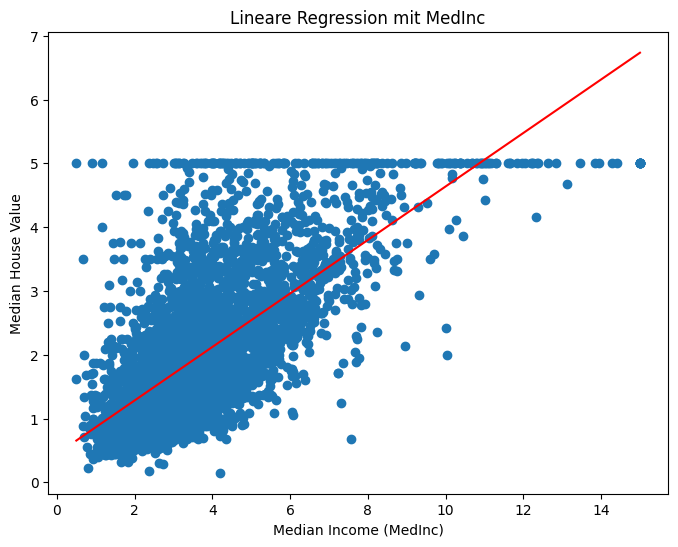

In [6]:
plt.figure(figsize=(8, 6))

# Scatterplot der Testdaten
plt.scatter(X_test, y_test)

# Regressionsgerade
x_vals = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
y_vals = model.predict(x_vals)

plt.plot(x_vals, y_vals, color='red')
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value")
plt.title("Lineare Regression mit MedInc")
plt.show()

## Von einem Merkmal zu allen 8 Merkmalen: Multivariate Regression

Bisher haben wir nur **ein Merkmal** (MedInc) verwendet:
```
y = β1 · MedInc + β0
```

Jetzt verwenden wir **alle 8 Merkmale** gleichzeitig:
```
y = w1·MedInc + w2·HouseAge + w3·AveRooms + w4·AveBedrms
  + w5·Population + w6·AveOccup + w7·Latitude + w8·Longitude + b
```

Das Modell lernt für **jedes Merkmal einen eigenen Koeffizienten** (Gewicht).
Trotzdem bleibt es **linear** – weil die Merkmale nur gewichtet addiert werden,
nie multipliziert oder potenziert.

> **Merksatz:** „Linear“ bezieht sich auf die Art der Verknüpfung, nicht auf
> die Anzahl der Merkmale. Ein Modell mit 100 Features ist immer noch linear.

**Leitfrage:** Verbessert sich R² durch mehr Merkmale – und warum?


# Variante B) Lineares Regressionsmodell mit allen 8 Merkmalen

## B.0. Bibliotheken importieren und Datensatz laden

In [7]:
california = fetch_california_housing(as_frame=True)

X = california.data        # Alle Features
y = california.target     # Median House Value
X.shape

(20640, 8)

## B.1. Train/Test-Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    # stratify nicht verfügbar bei Regression (y ist kontinuierlich, keine Klassen)
)

print(f"Trainingsdaten: {len(X_train):>6} Samples, {X_train.shape[1]} Merkmale")
print(f"Testdaten:      {len(X_test):>6} Samples, {X_test.shape[1]} Merkmale")


Trainingsdaten:  16512 Samples, 8 Merkmale
Testdaten:        4128 Samples, 8 Merkmale


## B.2. Lineares Regressionsmodell trainieren

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Lineares Regressionsmodell (alle Merkmale)")
print("-----------------------------------------")
print(f"Achsenabschnitt (β₀): {model.intercept_:.3f}")
print("Koeffizienten:")

coefficients = pd.DataFrame({
    "Merkmal": X.columns,
    "Koeffizient": model.coef_
}).sort_values(by="Koeffizient", key=abs, ascending=False)
print(coefficients)
print()

Lineares Regressionsmodell (alle Merkmale)
-----------------------------------------
Achsenabschnitt (β₀): -37.023
Koeffizienten:
      Merkmal  Koeffizient
3   AveBedrms     0.783145
0      MedInc     0.448675
7   Longitude    -0.433708
6    Latitude    -0.419792
2    AveRooms    -0.123323
1    HouseAge     0.009724
5    AveOccup    -0.003526
4  Population    -0.000002



### Interpretation der Koeffizienten

Die Tabelle zeigt, welche Merkmale das Modell als besonders einflussreich gewichtet.

**Lesehilfe:** Ein Koeffizient von +0.85 für MedInc bedeutet:
Bei einer Erhöhung des Median-Einkommens um 1 Einheit (= 10.000 USD)
steigt der vorhergesagte Hauspreis um 85.000 USD (= 0.85 × 100.000 USD),
wenn alle anderen Merkmale konstant bleiben.

> **Wichtig:** Koeffizienten sind nur direkt vergleichbar, wenn die Merkmale
> auf derselben Skala liegen. Latitude und Longitude (Koordinaten) haben eine
> andere Einheit als MedInc (Einkommen). Für einen fairen Vergleich würde
> man die Merkmale zuerst standardisieren (StandardScaler).


## B.3. Vorhersage und Modellgüte

In [10]:
y_pred_b = model.predict(X_test)

rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_b))
r2_b   = r2_score(y_test, y_pred_b)

print("Modellgüte (Variante B – alle 8 Merkmale)")
print("-------------------------------------------")
print(f"RMSE: {rmse_b:.3f}  (mittlerer Fehler in 100.000 USD)")
print(f"R²:   {r2_b:.3f}  (Anteil erklärter Varianz)")


Modellgüte (Variante B – alle 8 Merkmale)
-------------------------------------------
RMSE: 0.746  (mittlerer Fehler in 100.000 USD)
R²:   0.576  (Anteil erklärter Varianz)


## B.4. Visualisierung

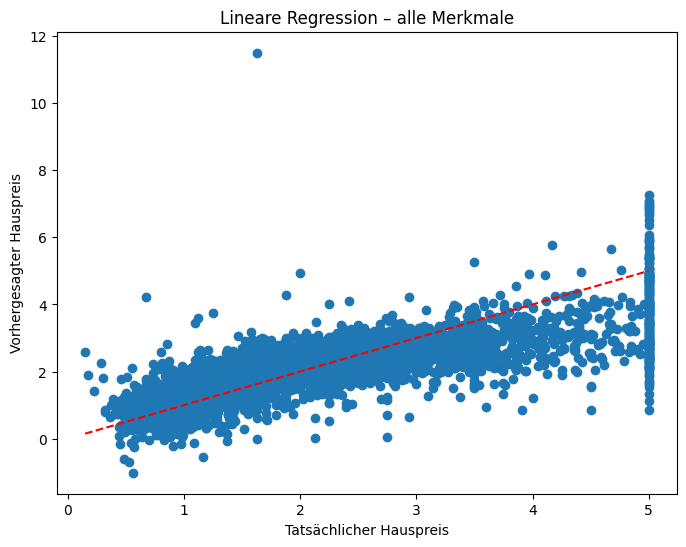

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_b)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--", color='red'
)

plt.ylabel("Vorhergesagter Hauspreis")
plt.xlabel("Tatsächlicher Hauspreis")
plt.title("Lineare Regression – alle Merkmale")
plt.show()

## Vergleich der Modellgüte

```python
# Hinweis: r2_a und r2_b wurden in den Schritten A.4 und B.3 berechnet
```


In [12]:
print("Vergleich: Modell A vs. Modell B")
print("-" * 40)
print(f"Modell A (1 Merkmal):   R² = {r2_a:.3f}  |  RMSE = {rmse_a:.3f}")
print(f"Modell B (8 Merkmale):  R² = {r2_b:.3f}  |  RMSE = {rmse_b:.3f}")
print()
print(f"Verbesserung R²:   +{r2_b - r2_a:.3f} ({(r2_b - r2_a) / r2_a * 100:.1f}% relativer Zuwachs)")
print(f"Verbesserung RMSE: {rmse_a - rmse_b:.3f} weniger Fehler durch mehr Merkmale")
print()
print("Interpretation:")
print(f"Modell B erklärt {r2_b:.1%} der Varianz – gegenüber {r2_a:.1%} bei Modell A.")
print("Mehr Merkmale helfen, aber lineare Regression hat auch mit allen 8 Grenzen.")
print("Der wahre Zusammenhang zwischen Features und Hauspreis ist nicht-linear.")


Vergleich: Modell A vs. Modell B
----------------------------------------
Modell A (1 Merkmal):   R² = 0.459  |  RMSE = 0.842
Modell B (8 Merkmale):  R² = 0.576  |  RMSE = 0.746

Verbesserung R²:   +0.117 (25.5% relativer Zuwachs)
Verbesserung RMSE: 0.097 weniger Fehler durch mehr Merkmale

Interpretation:
Modell B erklärt 57.6% der Varianz – gegenüber 45.9% bei Modell A.
Mehr Merkmale helfen, aber lineare Regression hat auch mit allen 8 Grenzen.
Der wahre Zusammenhang zwischen Features und Hauspreis ist nicht-linear.


## Exkurs: Warum wird die Feature-Matrix X bei der Linearen Regression nicht skaliert?

In Kapitel 3 haben wir gelernt: **Merkmale skalieren!**  
Hier passiert das nicht – warum?

### Was Skalierung bei Linearer Regression *nicht* verändert

Die Lineare Regression löst das Optimierungsproblem analytisch (Methode der kleinsten
Quadrate). Das Ergebnis ist **mathematisch invariant** gegenüber linearen Transformationen
der Features: Wenn man alle Werte z. B. durch 1000 dividiert, passt das Modell den
Koeffizienten automatisch an – das Produkt `w × x` bleibt gleich.

**Vorhersagen, R² und RMSE ändern sich dadurch nicht** – kein einziges Bit.

### Was Skalierung *doch* verändert: die Koeffizienten

Ohne Skalierung sind die Koeffizienten in den **Original-Einheiten** der jeweiligen
Features. Man kann sie dann nicht direkt miteinander vergleichen, weil
z. B. `Population` in Tausenden gemessen wird, `AveRooms` in einzelnen Zimmern.

| Situation | R² / RMSE | Koeffizienten | Koeffizienten vergleichbar? |
|---|---|---|---|
| Ohne Skalierung | identisch | abhängig von Original-Einheiten | Nein |
| Mit StandardScaler | identisch | in Einheiten von Standardabweichungen | **Ja** |

### Wann Skalierung zwingend notwendig ist

Bei diesen Algorithmen **verändern** sich Vorhersagen und Güte durch Skalierung:
- **k-Nearest Neighbors (KNN):** rechnet Abstände direkt – große Zahlenwerte dominieren
- **Support Vector Machine (SVM):** sucht den Margin in Feature-Einheiten
- **Neuronale Netze:** Gradienten explodieren oder verschwinden bei unterschiedlichen Skalen
- **Ridge / Lasso:** Regularisierung bestraft große Koeffizienten, nicht große Featurewerte

Lineare Regression ohne Regularisierung ist hier die **Ausnahme**, nicht die Regel.
Die Faustregel: **Im Zweifel immer skalieren** – es schadet nie, auch bei Linearer Regression.


In [13]:
# ── Demonstration: Skalierung verändert R² und RMSE NICHT ───────────────
from sklearn.preprocessing import StandardScaler

# Datensatz neu laden (alle 8 Merkmale, gleicher Split wie Variante B)
california_demo = fetch_california_housing(as_frame=True)
X_demo = california_demo.data
y_demo = california_demo.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)

# Modell A: OHNE Skalierung
model_unscaled = LinearRegression()
model_unscaled.fit(X_train_d, y_train_d)
y_pred_unscaled = model_unscaled.predict(X_test_d)
r2_unscaled   = r2_score(y_test_d, y_pred_unscaled)
rmse_unscaled = np.sqrt(mean_squared_error(y_test_d, y_pred_unscaled))

# Modell B: MIT StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_d)   # fit nur auf Trainingsdaten!
X_test_scaled  = scaler.transform(X_test_d)        # transform (kein fit!) auf Testdaten

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train_d)
y_pred_scaled = model_scaled.predict(X_test_scaled)
r2_scaled   = r2_score(y_test_d, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test_d, y_pred_scaled))

print("Vergleich: Lineare Regression mit vs. ohne Skalierung")
print("-" * 55)
print(f"{'':30s} {'Ohne Scaler':>12}  {'Mit Scaler':>12}")
print(f"{'R²':30s} {r2_unscaled:>12.6f}  {r2_scaled:>12.6f}")
print(f"{'RMSE':30s} {rmse_unscaled:>12.6f}  {rmse_scaled:>12.6f}")
print()
print("Fazit: R² und RMSE sind identisch.")
print("       Skalierung aendert die Vorhersagequalitaet bei Linearer")
print("       Regression NICHT. Nur die Koeffizienten aendern sich.")
print()

# ── Was sich ändert: die Koeffizienten ───────────────────────────────────
print("Koeffizienten im Vergleich:")
print(f"{'Feature':15s}  {'Ohne Scaler':>14}  {'Mit Scaler':>14}")
print("-" * 47)
for feat, w_unsc, w_sc in zip(
    X_demo.columns,
    model_unscaled.coef_,
    model_scaled.coef_
):
    print(f"{feat:15s}  {w_unsc:>14.4f}  {w_sc:>14.4f}")
print()
print("Die skalierten Koeffizienten sind direkt vergleichbar:")
print("Je groesser |Koeffizient|, desto staerker der Einfluss auf den Preis.")
print("(in Einheiten von Standardabweichungen)")


Vergleich: Lineare Regression mit vs. ohne Skalierung
-------------------------------------------------------
                                Ohne Scaler    Mit Scaler
R²                                 0.575788      0.575788
RMSE                               0.745581      0.745581

Fazit: R² und RMSE sind identisch.
       Skalierung aendert die Vorhersagequalitaet bei Linearer
       Regression NICHT. Nur die Koeffizienten aendern sich.

Koeffizienten im Vergleich:
Feature             Ohne Scaler      Mit Scaler
-----------------------------------------------
MedInc                   0.4487          0.8544
HouseAge                 0.0097          0.1225
AveRooms                -0.1233         -0.2944
AveBedrms                0.7831          0.3393
Population              -0.0000         -0.0023
AveOccup                -0.0035         -0.0408
Latitude                -0.4198         -0.8969
Longitude               -0.4337         -0.8698

Die skalierten Koeffizienten sind direkt vergl

## Musterlösung

**Mögliche Antworten**

1. Das Modell mit **mehreren Merkmalen** erzielt den höheren **R²-Wert**,
   weil es mehr erklärende Information nutzt.
2. Das ist plausibel: Hauspreise hängen nicht nur vom Einkommen ab,
   sondern auch von Lage, Größe, Alter des Gebäudes etc.
3. Nein. Ein höherer R²-Wert bedeutet nicht automatisch, dass alle
   relevanten Zusammenhänge erfasst sind. Auch Modell B erklärt
   nur ~58 % der Varianz – der Rest liegt an nicht-linearen Zusammenhängen,
   fehlenden Merkmalen oder Messungenauigkeiten.
4. Skalierung verändert bei der Linearen Regression **R², RMSE und Vorhersagen nicht**
   (siehe Exkurs). Sie verändert nur die Koeffizienten: Mit StandardScaler sind sie
   direkt vergleichbar, ohne Scaler hängen sie von den jeweiligen Feature-Einheiten ab.
   Bei anderen Algorithmen (KNN, SVM, neuronale Netze) ist Skalierung jedoch zwingend.
5. Der R²-Vergleich wird programmatisch berechnet – die Werte ändern sich
   automatisch, wenn Parameter wie `test_size` oder `random_state` angepasst werden.
